# Sleep Health & Lifestyle Notebook

## 1. Project Overview

This project builds a machine learning classification model that predicts whether a person is likely to
have a **sleep disorder**, based on everyday lifestyle and health metrics: stress level, sleep quality,
sleep duration, BMI category, heart rate, and blood pressure. The goal is to turn a set of simple,
easily-measured personal health indicators into an early, informal signal of sleep disorder risk, and to
deploy the trained model behind a usable desktop application.

## 2. Dataset

The dataset (`Sleep_Data_Sampled.csv`) contains lifestyle and health survey data for a sample of
individuals, including a labelled `Sleep Disorder` column (the presence or absence of a diagnosed
disorder), alongside features such as Stress Level, Quality of Sleep, Sleep Duration, BMI Category,
Heart Rate and Blood Pressure.

| Feature | Short Description |
| --- | --- |
| Person Id | Auto-generated Value |
| Age | Age of person |
| Occupation | Work Type |
| Sleep Duration | Hours slept|
| Sleep Quality | Sleep-quality score |
| BMI | Body composition category |
| Blood Pressure | Systolic/diastolic |
| Daily Steps| Physical activity |
| Heart Rate | Resting heart rate |
| Sleep Disorder | Unusual sleeping behaviour |

## 1. Import Libraries

### Explanation
This cell imports all the required Python libraries for data handling, modeling, and evaluation. We use NumPy for array operations, Matplotlib for plotting, and scikit-learn for machine learning models and metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import joblib


## 3. Data Loading
### Explanation
This cell loads the raw survey data from `Sleep_Data_Sampled.csv` into a pandas DataFrame using
`pd.read_csv`. Pandas is used here (rather than a lower-level tool like NumPy's `genfromtxt`) because the
dataset mixes numeric columns (Heart Rate, Sleep Duration) with text columns (BMI Category, Blood
Pressure), and DataFrames make it straightforward to clean, filter and transform columns of different
types together.


In [2]:
# Read File
filename = "Sleep_Data_Sampled.csv"
df = pd.read_csv(filename)

## 4. Data Cleaning
### Explanation
- **Missing `Sleep Disorder` values:** a blank entry in this column means no disorder was recorded for
  that person, so missing values are filled with `"Healthy"` rather than dropped, preserving every row in
  the dataset instead of losing data unnecessarily.
- **BMI standardisation:** the raw data contains the label `"Normal Weight"`, which is renamed to
  `"Normal"` so that BMI Category uses consistent, simplified labels before it's converted into a numeric
  feature in the next step.

In [3]:
# Cleaning data
df.fillna({"Sleep Disorder":"Healthy"} , inplace=True)

for x in df.index:
    if (df.loc[x,  "BMI Category"] == "Normal Weight"):
        df.loc[x, "BMI Category"] = "Normal"

## 5. Feature Engineering

### Explanation
Machine learning models need numeric input, so the categorical columns are converted into binary
features:
- **BMI → binary feature:** `BMI Category` is converted into a numeric `BMI` column, where `0` represents
  "Normal" and `1` represents any other category (e.g. Overweight, Obese).
- **Blood Pressure → Systolic/Diastolic:** the combined `"120/80"`-style string is split on the `/`
  character into two separate numeric columns, `Systolic BP` and `Diastolic BP`, since a single combined
  text field can't be used directly by a model.
- **Sleep Disorder → binary target:** the target column `SD` is created, where `0` means "Healthy" and `1`
  means a sleep disorder was recorded, turning the prediction problem into standard binary classification.

In [4]:
# Convert BMI Category to tangible values for models
df["BMI"]=0
for x in df.index:
    if (df.loc[x,  "BMI Category"] == "Normal"):
        df.loc[x, "BMI"] = 0
    else:
        df.loc[x, "BMI"] = 1
    
# Convert Sleep Disorder to tangible values for models
df["SD"]=0
for y in df.index:
    if (df.loc[y,  "Sleep Disorder"] == "Healthy"):
        df.loc[y, "SD"] = 0
    else:
        df.loc[y, "SD"] = 1

    
# Expanding Blood Pressure to Systolic BP | Diastolic BP
df[["Systolic BP", "Diastolic BP"]] = df["Blood Pressure"].str.split("/", expand=True)


## 6. Feature and Target Selection
### Explanation
`X` contains the seven input features the model will learn from: Stress Level, Quality of Sleep, Sleep
Duration, BMI, Heart Rate, Systolic BP and Diastolic BP. `y` contains the target the model is trying to
predict: whether a sleep disorder (`SD`) is present. Separating features from the target like this is a
standard first step before splitting data for training.

In [5]:
# Created a target Column and 
X = df[["Stress Level","Quality of Sleep","Sleep Duration","BMI","Heart Rate","Systolic BP", "Diastolic BP"]]
y = df[["SD"]]

# Display info
print("Data shape:", df.shape)
print("Feature shape:", X.shape, "Target shape:", y.shape)

df.to_csv("Sleep_Health_Cleaned.csv", index=False)

Data shape: (15000, 17)
Feature shape: (15000, 7) Target shape: (15000, 1)


## 7. Split into Train, Validation, and Test Sets

### Explanation
The dataset is split into three parts: a **training set** (60%) used to fit each model, a **validation
set** (20%) used to compare models and pick the best one, and a **test set** (20%) held back entirely for
a final, unbiased evaluation of the chosen model. `stratify=y` ensures the proportion of "Healthy" vs.
"disorder" cases stays consistent across all three sets, rather than risking an imbalanced split by
chance.

In [6]:

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)


Train set: (9000, 7)
Validation set: (3000, 7)
Test set: (3000, 7)


In [7]:

def plot_confusion_matrix(cm, title):
    fig, ax = plt.subplots(figsize=(3.5,3.5))
    ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    plt.show()


## 8. Model Training

Each model is trained with `.fit(X_train, y_train)`, then evaluated on both the validation and test sets
using `accuracy_score` and `confusion_matrix`.

Five classification models are trained on the same training data, so their performance can be fairly
compared:

- **Logistic Regression** — a simple, interpretable linear model that estimates the probability of each
  class; a good baseline for binary classification problems.

c:\Users\Vanessa Aigbekaen\Downloads\Personal Project\Completed Projects\Time Series Forecasting Model\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Validation Accuracy: 0.9286666666666666 
Test Accuracy: 0.9306666666666666


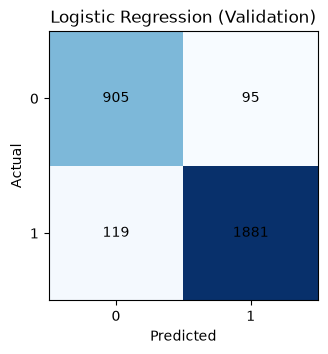

In [8]:

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_val_lr = log_reg.predict(X_val)
y_test_lr = log_reg.predict(X_test)
val_acc_lr = accuracy_score(y_val, y_val_lr)
test_acc_lr = accuracy_score(y_test, y_test_lr)
cm_lr = confusion_matrix(y_val, y_val_lr)
print("Validation Accuracy:", val_acc_lr, "\nTest Accuracy:", test_acc_lr)
plot_confusion_matrix(cm_lr, "Logistic Regression (Validation)")


- **K-Nearest Neighbours (KNN)** — a non-parametric method that classifies a new point by majority vote
  among its `k` closest training examples; works well when classes form clear clusters.

Validation Accuracy: 0.9593333333333334 
Test Accuracy: 0.9643333333333334


c:\Users\Vanessa Aigbekaen\Downloads\Personal Project\Completed Projects\Time Series Forecasting Model\.venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


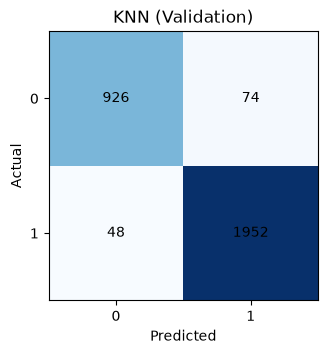

In [9]:

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_val_knn = knn.predict(X_val)
y_test_knn = knn.predict(X_test)
val_acc_knn = accuracy_score(y_val, y_val_knn)
test_acc_knn = accuracy_score(y_test, y_test_knn)
cm_knn = confusion_matrix(y_val, y_val_knn)
print("Validation Accuracy:", val_acc_knn, "\nTest Accuracy:", test_acc_knn)
plot_confusion_matrix(cm_knn, "KNN (Validation)")



- **Naive Bayes** — a fast probabilistic model based on Bayes' theorem, assuming features are independent;
  often used as a quick baseline despite that simplifying assumption.


Validation Accuracy: 0.926 
Test Accuracy: 0.9243333333333333


c:\Users\Vanessa Aigbekaen\Downloads\Personal Project\Completed Projects\Time Series Forecasting Model\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


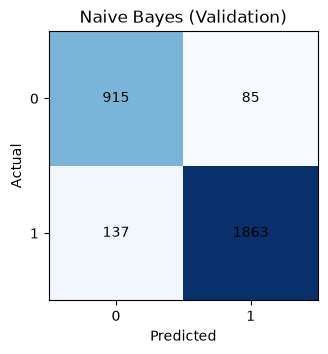

In [10]:

nb = GaussianNB()
nb.fit(X_train, y_train)
y_val_nb = nb.predict(X_val)
y_test_nb = nb.predict(X_test)
val_acc_nb = accuracy_score(y_val, y_val_nb)
test_acc_nb = accuracy_score(y_test, y_test_nb)
cm_nb = confusion_matrix(y_val, y_val_nb)
print("Validation Accuracy:", val_acc_nb, "\nTest Accuracy:", test_acc_nb)
plot_confusion_matrix(cm_nb, "Naive Bayes (Validation)")


- **Random Forest** — an ensemble of many decision trees, each trained on a random subset of the data,
  with predictions combined by majority vote; generally robust and resistant to overfitting.

c:\Users\Vanessa Aigbekaen\Downloads\Personal Project\Completed Projects\Time Series Forecasting Model\.venv\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Validation Accuracy: 0.9666666666666667 
Test Accuracy: 0.967


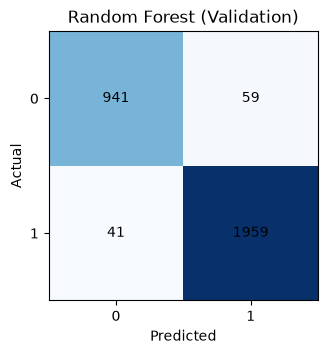

In [11]:

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_val_rf = rf.predict(X_val)
y_test_rf = rf.predict(X_test)
val_acc_rf = accuracy_score(y_val, y_val_rf)
test_acc_rf = accuracy_score(y_test, y_test_rf)
cm_rf = confusion_matrix(y_val, y_val_rf)
print("Validation Accuracy:", val_acc_rf, "\nTest Accuracy:", test_acc_rf)
plot_confusion_matrix(cm_rf, "Random Forest (Validation)")


- **Gradient Boosting** — an ensemble that builds trees sequentially, with each new tree correcting the
  errors of the previous ones; can be highly accurate but more prone to overfitting if not tuned carefully.

c:\Users\Vanessa Aigbekaen\Downloads\Personal Project\Completed Projects\Time Series Forecasting Model\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Validation Accuracy: 0.949 
Test Accuracy: 0.95


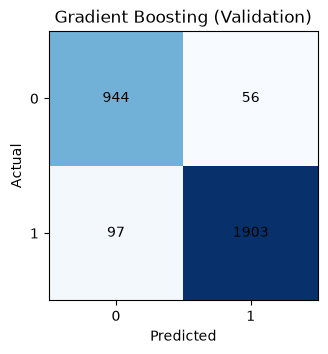

In [12]:

gbt = GradientBoostingClassifier(random_state=42)
gbt.fit(X_train, y_train)
y_val_gbt = gbt.predict(X_val)
y_test_gbt = gbt.predict(X_test)
val_acc_gbt = accuracy_score(y_val, y_val_gbt)
test_acc_gbt = accuracy_score(y_test, y_test_gbt)
cm_gbt = confusion_matrix(y_val, y_val_gbt)
print("Validation Accuracy:", val_acc_gbt, "\nTest Accuracy:", test_acc_gbt)
plot_confusion_matrix(cm_gbt, "Gradient Boosting (Validation)")


## 9. Model Evaluation

### Confusion Matrices
Each model's confusion matrix (plotted with `plot_confusion_matrix`) shows how many predictions were
correct versus incorrect for each class, broken down into true positives, true negatives, false positives
and false negatives. This gives a more detailed picture than accuracy alone, since it shows *which* kind
of mistake a model tends to make.

### Accuracy Comparison
A bar chart compares each model's validation and test accuracy side by side. Plotting both scores together
makes it easy to spot a model that performs well on validation data but noticeably worse on the held-out
test set, a sign of possible overfitting.

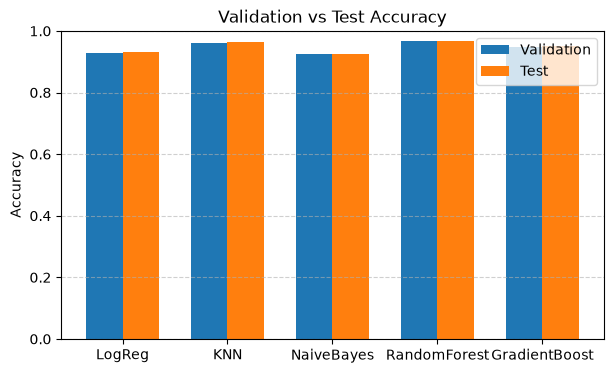

In [13]:

models = ["LogReg", "KNN", "NaiveBayes", "RandomForest", "GradientBoost"]
val_accs = [val_acc_lr, val_acc_knn, val_acc_nb, val_acc_rf, val_acc_gbt]
test_accs = [test_acc_lr, test_acc_knn, test_acc_nb, test_acc_rf, test_acc_gbt]

x = np.arange(len(models))
width = 0.35
plt.figure(figsize=(7,4))
plt.bar(x - width/2, val_accs, width, label="Validation")
plt.bar(x + width/2, test_accs, width, label="Test")
plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Validation vs Test Accuracy")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


### ROC Curves and AUC
For each model that supports probability estimates, an ROC (Receiver Operating Characteristic) curve is
plotted, showing the trade-off between true positive rate and false positive rate at different decision
thresholds. The AUC (Area Under the Curve) score summarises this into a single number: closer to 1.0 means
better separation between the two classes, while 0.5 is no better than random guessing.

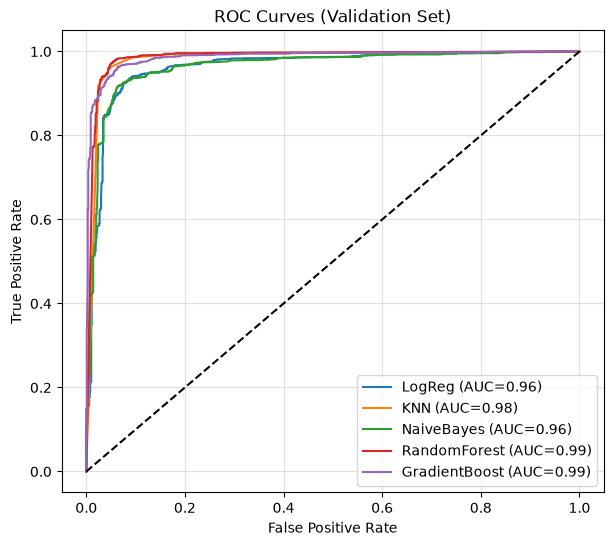

In [14]:

plt.figure(figsize=(7,6))
for name, model in [("LogReg", log_reg), ("KNN", knn), ("NaiveBayes", nb), ("RandomForest", rf), ("GradientBoost", gbt)]:
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)[:, 1]
        fpr, tpr, _ = roc_curve(y_val, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Validation Set)")
plt.legend(loc="lower right")
plt.grid(alpha=0.4)
plt.show()


## 10. Model Selection
### Explanation
The validation accuracy of all five models is collected into a dictionary, and the model with the highest
validation accuracy is selected as the final model. **Random Forest** was selected using this approach,
as it achieved the highest validation accuracy of the five models tested. Validation accuracy (rather than
training accuracy) is used for this decision because it reflects how well each model generalises to data
it wasn't directly trained on.



In [15]:

val_scores = {
    "Logistic Regression": val_acc_lr,
    "K-Nearest Neighbors": val_acc_knn,
    "Naive Bayes": val_acc_nb,
    "Random Forest": val_acc_rf,
    "Gradient Boosting": val_acc_gbt
}
best_model_name = max(val_scores, key=val_scores.get)
print("Best model based on validation accuracy:", best_model_name)

best_model = {
    "Logistic Regression": log_reg,
    "K-Nearest Neighbors": knn,
    "Naive Bayes": nb,
    "Random Forest": rf,
    "Gradient Boosting": gbt
}[best_model_name]




Best model based on validation accuracy: Random Forest


# 11. Saving the Model

### Explanation
`joblib` is used to serialise the trained model object to disk as `best_health_model.joblib`. This means
the model doesn't need to be retrained every time it's used: the saved file can be loaded directly by the
desktop GUI application (`sleep_health_gui.py`) with `joblib.load(...)`, allowing it to make instant
predictions on new user input without needing access to this notebook, the training data, or scikit-learn
training code at runtime.

In [16]:
joblib.dump(best_model, "best_health_model.joblib")
print("Saved best model to best_health_model.joblib")

Saved best model to best_health_model.joblib


## 12. Limitations

- The dataset is a sample, not a full clinical dataset, so results may not generalise to the wider
  population.
- BMI is reduced to a binary feature (Normal vs. Other), which loses information compared to using the
  original categories or a continuous BMI value.
- The model relies on self-reported and survey-style data (e.g. Stress Level, Quality of Sleep), which is
  inherently subjective and less precise than clinical measurements.
- No cross-validation was used — a single train/validation/test split means the reported accuracy could
  vary somewhat with a different random split.
- The model has not been validated by any medical professional and should not be used for real diagnosis.

## 13. Future Improvements

- Add k-fold cross-validation for a more robust estimate of model performance.
- Explore additional features (e.g. age, occupation, physical activity level) if available in extended
  data.
- Add feature-importance or SHAP analysis to show which inputs most influence each prediction.
- Package the GUI as a standalone executable so it can run without a Python environment installed.
- Deploy the model as a web application for wider accessibility.

## 14. Resources

- scikit-learn documentation: https://scikit-learn.org/stable/documentation.html
- pandas documentation: https://pandas.pydata.org/docs/
- joblib documentation: https://joblib.readthedocs.io/